In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Entregável 1 NumPy

### A. Criando arrays

In [47]:
df = pd.read_csv('../../data/vendas_brasil_1.csv')

preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
quantidade= df['quantidade'].to_numpy()
desconto_pct = df['desconto_pct'].to_numpy()
receita_total = df['receita_total'].to_numpy()
frete = df['frete'].to_numpy()

print(preco_unitario)
print(custo_unitario)
print(quantidade)
print(desconto_pct)
print(receita_total)
print(frete)


[ 739.39  187.48   76.11 ...   55.15  197.09 1057.41]
[561.75 135.15  61.4  ...  36.94 167.23 870.69]
[10  5 14 ...  7  7  4]
[ 5.2  0.6  0.7 ...  0.  10.9 10. ]
[6933.48  930.28 1058.5  ...  384.44 1960.18 3795.73]
[ 8.68   nan  7.98 ... 85.35 30.99 27.23]


### B. Cálculos com operações vetorizadas

In [48]:
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto_pct / 100)
custo_total = custo_unitario * quantidade
lucro_estimado = receita_total - custo_total

print(valor_bruto)
print(valor_desconto)
print(custo_total)
print(lucro_estimado)


[7393.9   937.4  1065.54 ...  386.05 1379.63 4229.64]
[384.4828    5.6244    7.45878 ...   0.      150.37967 422.964  ]
[5617.5   675.75  859.6  ...  258.58 1170.61 3482.76]
[1315.98  254.53  198.9  ...  125.86  789.57  312.97]


### C. Máscaras booleanas

In [49]:
receita_acima_media = receita_total > receita_total.mean()
prejuizo = lucro_estimado < 0
desconto_alto = desconto_pct > 20

print(receita_acima_media.sum())
print(prejuizo.sum())
print(desconto_alto.sum())


9236
2168
7037


### D. Agregações

In [50]:
receita_media = receita_total.mean()
maior_receita = receita_total.max()
menor_receita = receita_total.min()
lucro_medio = lucro_estimado.mean()
qtd_vendas_prejuizo = prejuizo.sum()

print(receita_media)
print(maior_receita)
print(menor_receita)
print(lucro_medio)
print(qtd_vendas_prejuizo)


1891.6881729005502
58430.28
3.7
513.187152883005
2168


### Conclusão Entregável 1

No geral, a maioria das vendas gerou lucro positivo. A receita média é de aproximadamente 1891,69 e o lucro médio fica em torno de 513,19, então o lucro médio é positivo. Das 37617 vendas do dataset, 9236 têm receita acima da média, 2168 têm prejuízo e 7037 tiveram desconto alto. A receita por venda também varia bastante, indo de 3,70 até 58430,28. 

# Entregável 2 Pandas

## A. Primeiro olhar no dataset

In [51]:
df = pd.read_csv('../../data/vendas_brasil_1.csv')
df.head(200)

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-04-17,4,Recife,App Mobile,Esportes,Tapete de Yoga,Gabi Alves,Prata,283.04,227.67,...,11,19.6,2488.61,38.17,3.02,12.0,False,True,False,False
196,2022-08-21,8,Rio de Janeiro,Marketplace,Eletrônicos,Smartphone,Inês Nunes,Ouro,888.33,643.11,...,11,1.0,9627.96,50.49,4.03,18.0,False,True,False,True
197,2023-11-23,11,Curitiba,Televendas,Vestuário,Bermuda,Diego Ferreira,Diamante,77.71,55.60,...,2,5.7,193.80,34.10,4.96,13.0,False,True,True,False
198,2022-04-23,4,Belo Horizonte,Site Web,Esportes,Bicicleta,Gabi Alves,Diamante,304.35,205.74,...,2,4.4,584.15,8.53,5.00,NaN,False,True,False,False


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [53]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [54]:
df.shape

(37617, 21)

In [55]:
df.isna()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37612,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
37613,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37614,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37615,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [56]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

**1. Quantas linhas e colunas existem?**

O dataset possui 37617 linhas e 21 colunas (essa informação pode ser vista no df.info() ou df.shape)

**2. Existem dados faltantes?**

Sim. Usando df.isna() podemos enxergar algumas células com o valor True (o que significa que ela possui um valor nulo). Com o df.isna().sum(), podemos ter a quantidade exata de dados nulos em cada coluna.

**3. Quais colunas parecem numéricas?**

mes, preço_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias

**4. Quais colunas parecem categóricas?**

data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco



## B. Limpeza e tratamento

**Converta a coluna de data para o tipo datetime**

In [57]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed')

In [58]:
df.head(200)

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-04-17,4,Recife,App Mobile,Esportes,Tapete de Yoga,Gabi Alves,Prata,283.04,227.67,...,11,19.6,2488.61,38.17,3.02,12.0,False,True,False,False
196,2022-08-21,8,Rio de Janeiro,Marketplace,Eletrônicos,Smartphone,Inês Nunes,Ouro,888.33,643.11,...,11,1.0,9627.96,50.49,4.03,18.0,False,True,False,True
197,2023-11-23,11,Curitiba,Televendas,Vestuário,Bermuda,Diego Ferreira,Diamante,77.71,55.60,...,2,5.7,193.80,34.10,4.96,13.0,False,True,True,False
198,2022-04-23,4,Belo Horizonte,Site Web,Esportes,Bicicleta,Gabi Alves,Diamante,304.35,205.74,...,2,4.4,584.15,8.53,5.00,NaN,False,True,False,False


**Padronize pelo menos uma coluna categórica que tenha valores escritos de formas
diferentes**

Padronizei a coluna produto tirando os espaços no início e no fim de cada categoria.

In [59]:
#Verificando valores despadronizados
df['produto'].unique()

<StringArray>
[             'Notebook',              'Camiseta',                 'Tênis',
           'Calça Jeans',             'Bicicleta',      'Machine Learning',
     'Python para Dados',          'Mel Orgânico',          'Whey Protein',
               'Bermuda',               'Jaqueta',               'Raquete',
            'Smartphone',        'Álgebra Linear',            'Smartwatch',
      ' Garrafa Térmica',              ' Jaqueta',           'Luva de Box',
         'Cálculo Vol.1',       'Barra de Cereal',  'Estatística Aplicada',
                'Tablet',       'Garrafa Térmica',        'Tapete de Yoga',
        'Fone Bluetooth',                'Azeite',               'Granola',
      'Barra de Cereal ',       ' Fone Bluetooth',       ' Tapete de Yoga',
             ' Notebook',            ' Bicicleta',              'Raquete ',
             'Camiseta ',              'Bermuda ',       'Fone Bluetooth ',
               ' Azeite',        'Cálculo Vol.1 ',           'Smartphone '

In [60]:
df['produto'] = df['produto'].str.strip()
df['produto'].unique()

<StringArray>
[            'Notebook',             'Camiseta',                'Tênis',
          'Calça Jeans',            'Bicicleta',     'Machine Learning',
    'Python para Dados',         'Mel Orgânico',         'Whey Protein',
              'Bermuda',              'Jaqueta',              'Raquete',
           'Smartphone',       'Álgebra Linear',           'Smartwatch',
      'Garrafa Térmica',          'Luva de Box',        'Cálculo Vol.1',
      'Barra de Cereal', 'Estatística Aplicada',               'Tablet',
       'Tapete de Yoga',       'Fone Bluetooth',               'Azeite',
              'Granola']
Length: 25, dtype: str

In [61]:
df['canal_venda'].unique()

<StringArray>
[ 'App Mobile',    'Site Web', 'Loja Física', 'Marketplace',  'Televendas',
  'APP Mobile',    'site web',    'Site web',  'app mobile',     'SiteWeb',
           nan, 'Loja Fisica',  'App mobile', 'loja física', 'Loja fisica']
Length: 15, dtype: str

In [62]:
df['canal_venda'] = df['canal_venda'].str.strip().str.title()

correcoes = {
    'Siteweb': 'Site Web',
    'Loja Fisica': 'Loja Física'
}

df['canal_venda'] = df['canal_venda'].replace(correcoes)
df['canal_venda'].unique()

<StringArray>
['App Mobile', 'Site Web', 'Loja Física', 'Marketplace', 'Televendas', nan]
Length: 6, dtype: str

In [63]:
df['cidade'].unique()

<StringArray>
[ 'Rio de Janeiro',          'Manaus',         'Goiânia',       'Fortaleza',
  'Belo Horizonte',          'Recife',       'São Paulo',    'Porto Alegre',
        'Salvador',        'Curitiba',        'salvador', 'Belo Horizonte ',
  'Rio de janeiro',         'Curtiba',       'Curitiba ',              'SP',
      ' Fortaleza',        'curitiba',              'RJ',        'S. Paulo',
       ' Salvador',         'Manaus ',       'São paulo',      'Fortaleza ',
       'Sao Paulo',              'BH', 'Rio de Janeiro ', ' Belo Horizonte',
         ' Recife',        'Slavador',  'Belo horizonte',             'Rio',
       ' Curitiba',         ' Manaus',        ' Goiânia',         'Recife ',
    'B. Horizonte',   'Porto Alegre ',  'Rio De Janeiro',      'São Paulo ',
        'Goiânia ',   ' Porto Alegre',       'Salvador ', ' Rio de Janeiro',
      ' São Paulo']
Length: 45, dtype: str

In [64]:
cidade_map = {
    'rio de janeiro': 'Rio de Janeiro',
    'rio': 'Rio de Janeiro',
    'rj': 'Rio de Janeiro',
    'são paulo': 'São Paulo',
    'sao paulo': 'São Paulo',
    'sp': 'São Paulo',
    's. paulo': 'São Paulo',
    'belo horizonte': 'Belo Horizonte',
    'bh': 'Belo Horizonte',
    'b. horizonte': 'Belo Horizonte',
    'manaus': 'Manaus',
    'goiânia': 'Goiânia',
    'fortaleza': 'Fortaleza',
    'recife': 'Recife',
    'porto alegre': 'Porto Alegre',
    'salvador': 'Salvador',
    'slavador': 'Salvador',
    'curitiba': 'Curitiba',
    'curtiba': 'Curitiba',
}

df['cidade'] = df['cidade'].str.strip().str.lower().map(cidade_map)
df['cidade'].unique()


<StringArray>
['Rio de Janeiro',         'Manaus',        'Goiânia',      'Fortaleza',
 'Belo Horizonte',         'Recife',      'São Paulo',   'Porto Alegre',
       'Salvador',       'Curitiba']
Length: 10, dtype: str

**Trate alguns dados faltantes de forma adequada**

Decidi tratar as colunas canal_venda e vendedor colocando os valores "Desconhecido" e "Não informado"

In [65]:
df['canal_venda'] = df['canal_venda'].fillna('Desconhecido')
df['vendedor'] = df['vendedor'].fillna('Não Informado')

df.head(2000)

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2022-02-08,2,Belo Horizonte,Televendas,Eletrônicos,Smartwatch,Henrique Dias,Bronze,937.40,646.42,...,12,4.6,10768.22,6.69,4.05,18.0,False,False,False,True
1996,2022-08-11,8,São Paulo,Site Web,Esportes,Raquete,Henrique Dias,Prata,168.92,137.84,...,3,14.6,433.85,8.12,4.05,2.0,False,True,False,False
1997,2022-07-03,7,Recife,Marketplace,Alimentação,Whey Protein,Ana Lima,Bronze,51.67,33.43,...,7,0.0,359.38,19.62,3.46,5.0,False,True,False,False
1998,2023-05-10,5,São Paulo,Televendas,Vestuário,Camiseta,Inês Nunes,Diamante,129.95,87.45,...,2,0.8,259.07,36.20,3.48,NaN,False,True,False,False


## C. Criação de novas colunas

In [66]:
df['ano_venda'] = df['data_venda'].dt.year
df['lucro_total'] = df['receita_total'] - (df['custo_unitario'] * df['quantidade'])
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Baixa' if x < 500 else ('Média' if x < 2000 else 'Alta'))

df.head(200)


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,lucro_total,faixa_receita
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,1315.98,Alta
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,NaN,4.98,19.0,True,False,False,False,2023,254.53,Média
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,2022,198.90,Média
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,2022,618.60,Média
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,2022,0.39,Baixa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2023-04-17,4,Recife,App Mobile,Esportes,Tapete de Yoga,Gabi Alves,Prata,283.04,227.67,...,38.17,3.02,12.0,False,True,False,False,2023,-15.76,Alta
196,2022-08-21,8,Rio de Janeiro,Marketplace,Eletrônicos,Smartphone,Inês Nunes,Ouro,888.33,643.11,...,50.49,4.03,18.0,False,True,False,True,2022,2553.75,Alta
197,2023-11-23,11,Curitiba,Televendas,Vestuário,Bermuda,Diego Ferreira,Diamante,77.71,55.60,...,34.10,4.96,13.0,False,True,True,False,2023,82.60,Baixa
198,2022-04-23,4,Belo Horizonte,Site Web,Esportes,Bicicleta,Gabi Alves,Diamante,304.35,205.74,...,8.53,5.00,NaN,False,True,False,False,2022,172.67,Média


## D. Filtros

In [67]:
vendas_receita_alta = df[df['receita_total'] > 5000]
vendas_devolucao = df[df['devolucao'] == True]
vendas_eletronicos = df[df['categoria'] == 'Eletrônicos']

print(vendas_receita_alta.shape[0])
print(vendas_devolucao.shape[0])
print(vendas_eletronicos.shape[0])


4004
3532
7515


Apenas 4004 vendas de 37617 têm receita acima de 5000, já que a maior parte do dataset está em faixas de receita mais baixas. 3532 vendas tiveram devolução e 7515 são eletrônicos.

## E. Agrupamentos com groupby

In [68]:
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
vendas_por_canal = df.groupby('canal_venda').size().sort_values(ascending=False)
receita_por_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
lucro_por_categoria = df.groupby('categoria')['lucro_total'].sum().sort_values(ascending=False)

print(receita_por_categoria)
print(vendas_por_canal)


categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64
canal_venda
Site Web        11346
App Mobile      11258
Loja Física      7498
Marketplace      5604
Televendas       1861
Desconhecido       50
dtype: int64


In [69]:
print(lucro_por_categoria)

categoria
Eletrônicos    12192275.55
Esportes        3133196.10
Vestuário       1849449.96
Livros          1225652.89
Alimentação      903986.63
Name: lucro_total, dtype: float64


Eletrônicos é a categoria com maior receita total. 

O Site Web é o canal com mais vendas.

Eletronicos também possui o maior lucro.

## F. Merge

In [70]:

regioes = pd.DataFrame({
    'cidade': ['Rio de Janeiro', 'São Paulo', 'Belo Horizonte', 'Manaus', 'Goiânia',
               'Fortaleza', 'Recife', 'Porto Alegre', 'Salvador', 'Curitiba'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Norte', 'Centro-Oeste',
               'Nordeste', 'Nordeste', 'Sul', 'Nordeste', 'Sul']
})

df = df.merge(regioes, on='cidade')

receita_por_regiao = df.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
vendas_por_regiao = df.groupby('regiao').size().sort_values(ascending=False)

print(receita_por_regiao)
print(vendas_por_regiao)


regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64
regiao
Nordeste        11366
Sudeste         11098
Sul              7564
Norte            3804
Centro-Oeste     3785
dtype: int64


Criei uma tabela relacionando cada cidade à sua região. Depois do merge, a região Nordeste aparece em primeiro lugar em receita total e em quantidade de vendas, com a região Sudeste logo atrás.

## Conclusão Entregável 2

Depois da análise e limpeza, ficou claro que o dataset tem alguns problemas de padronização em algumas colunas. Mesmo assim, conseguimos tirar alguns dados consistentes como a categoria de eletrônicos tendo a maior receita e lucro ou com a região Nordeste e Sudeste concentrando a maior parte do faturamento.

# Entregável 3 Seaborn

## A. Gráfico de barras

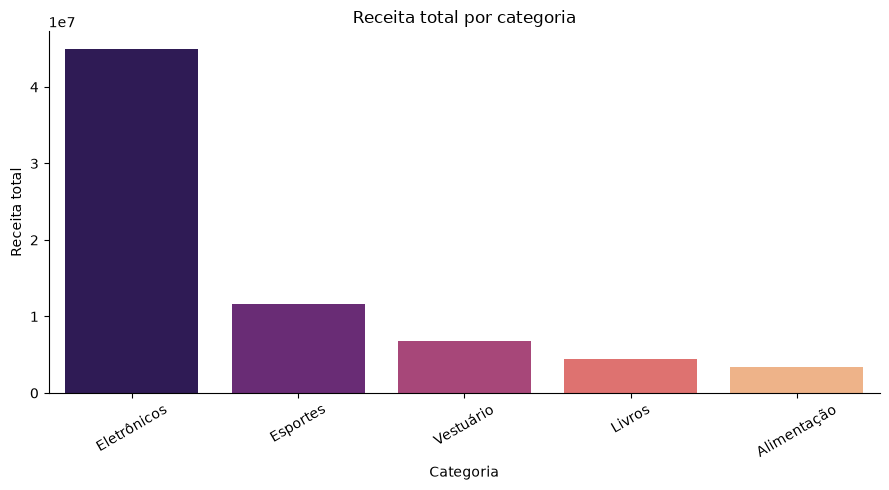

In [71]:
receita_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=receita_categoria.index, y=receita_categoria.values, hue=receita_categoria.index,
            palette='magma', legend=False)
plt.title('Receita total por categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita total')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()


Como a gente já viu no entregável 2, eletrônicos segue com uma receita maior que as demais categorias.

## B. Gráfico de linha

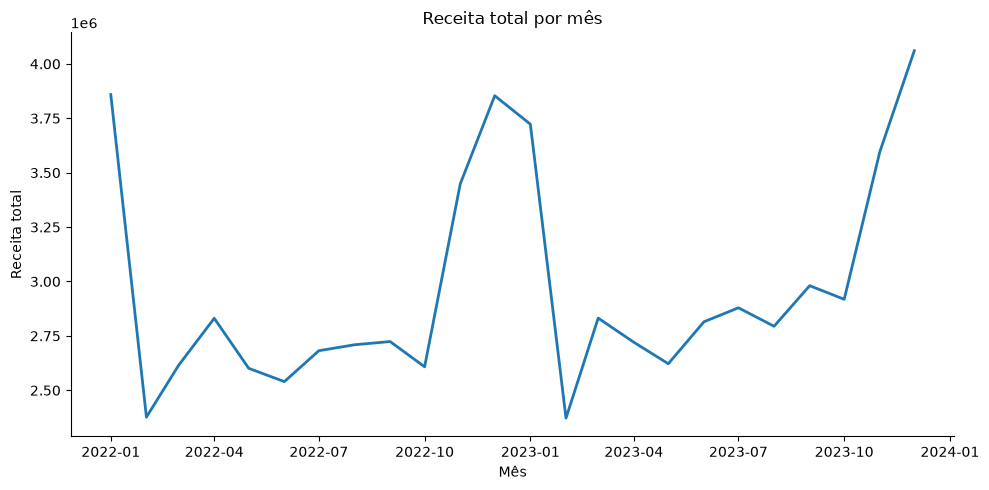

In [72]:
receita_mensal = df.groupby(df['data_venda'].dt.to_period('M'))['receita_total'].sum()
receita_mensal.index = receita_mensal.index.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(x=receita_mensal.index, y=receita_mensal.values, linewidth=2)
plt.title('Receita total por mês')
plt.xlabel('Mês')
plt.ylabel('Receita total')
sns.despine()
plt.tight_layout()
plt.show()


O gráfico de receita total por mês pode sugrir uma certa sazonalidade, visto que a curva em 2022 se comporta de forma parecida que a curva em 2023 (com os momentos de alta e baixa parecidos). Porém, mesmo assim, é dificil cravar pois apenas estamos vendo dois anos nesse dataset.

## C. Gráfico de dispersão

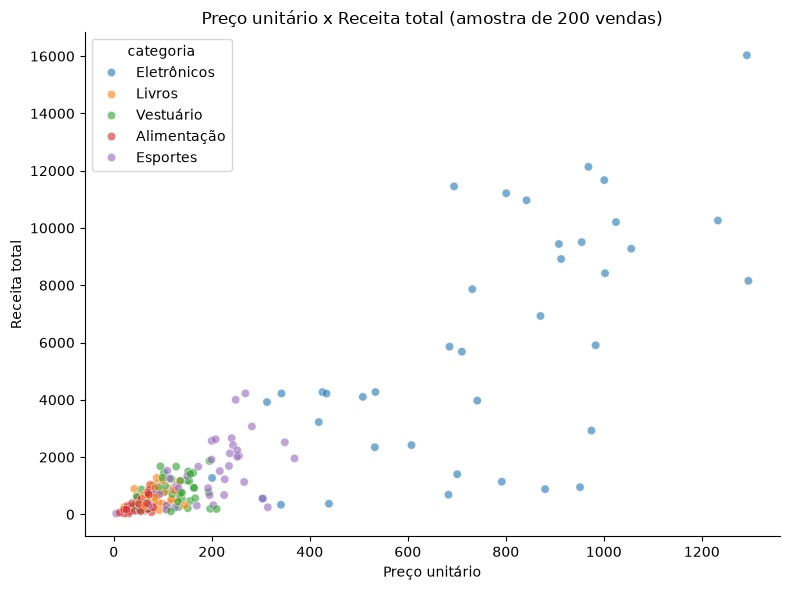

In [73]:
amostra = df.sample(200, random_state=20)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=amostra, x='preco_unitario', y='receita_total', alpha=0.6, hue='categoria')
plt.title('Preço unitário x Receita total (amostra de 200 vendas)')
plt.xlabel('Preço unitário')
plt.ylabel('Receita total')
sns.despine()
plt.tight_layout()
plt.show()


Analisando o preço unitário com a receita no gráfico, percebemos que quanto maior o preço unitário, maior a receita total (o que faz sentido já que o preço unitário é usado no cálculo da receita). Além disso colori os pontos pela categoria, revelando uma predominância de pontos de eletrônicos na media que o preço unitário e a receita aumentam.

## D. Mapa de calor

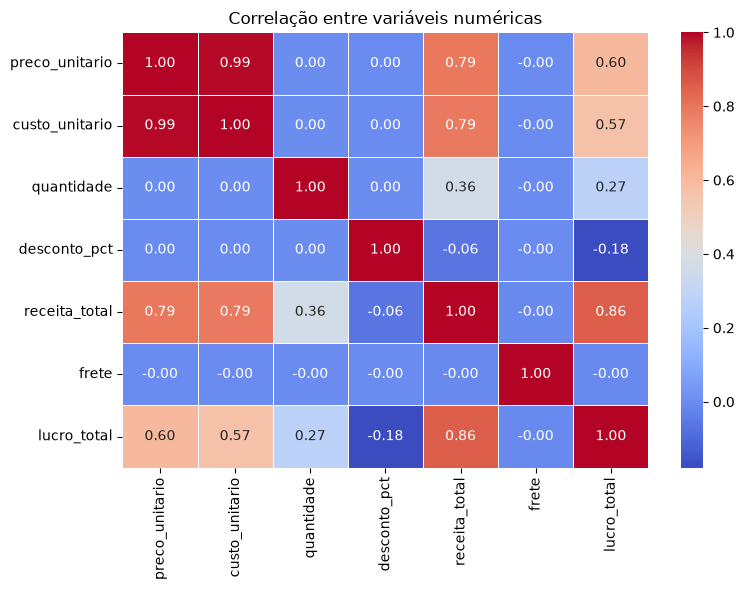

In [76]:
colunas_numericas = ['preco_unitario', 'custo_unitario', 'quantidade', 'desconto_pct',
                      'receita_total', 'frete', 'lucro_total']
correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()


A receita_total e o lucro_total têm correlação forte entre si, o que é esperado já que o lucro depende diretamente da receita. Já preco_unitario e custo_unitario também são fortemente correlacionados entre si, mas têm correlação fraca com desconto_pct e frete, mostrando que essas duas últimas variáveis se comportam de forma bem independente do restante.

## Conclusão Entregável 3

Os gráficos reforçam o que já havia aparecido no Pandas: Eletrônicos concentra a maior receita, a receita aumenta em relação ao preço unitário, o desconto não tem relação direta com o valor da venda, e a receita/lucro são as variáveis mais correlacionadas entre si no dataset.